### Explore A Jain's IEI pipeline
### Julian Moran
### 2026-02-09

In [13]:
import logging
import os

from dotenv import load_dotenv
from matplotlib.ticker import FuncFormatter
from matplotlib import pyplot as plt
from pathlib import Path
from typing import Tuple

import numpy as np
import polars as pl

# Env
pl.Config.set_tbl_rows(10)
load_dotenv("../.env")
INSTALL_PATH = os.environ["INSTALL_PATH"]

# Logging
logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s:%(name)s:%(message)s"
)
logger = logging.getLogger(__name__)

# Pipeline IO

Codebase at `/hpf/projects/CTrost/ajain/IEI_project/foldseek_AJ` 

1. DefenseFinder RefSeq IDs --> UniProt IDs
    - DefenseFinder: db of all bacterial genes implicated in antiphage systems
    - RefSeq bacterial accession IDs:   denote a bacterial immunoprotein; often begin with `WP`
    - UniProt access IDs:               denote a protein; e.g. `A0A7P0TAE1_HUMAN`

<br>

2. UniProt IDs --> Foldseek cluster ID

<br>

3. Foldseek cluster ID --> related human cluster ID

<br>

4. UniProt IDs --> UniprotKB annotations

<br>


# Questions

1. How does `01_RefSeq2Uniprot_mapping/` fit into the pipeline?
    - Are data in `01_RefSeq2Uniprot_mapping/` the output from pipeline step 2.?
    - Are data in `griid_gene_list/`, `gasdermin/`, `vipirin/`, `zorya/` prioritized subsets from `01_RefSeq2Uniprot_mapping/`?
    - If so, why are the subsets substantially larger than the original data?
    - `WP_063110969.1`, from `gasdermin/2025-07-26_gasdermin_annotated.xlsx`, is not in `data_local/01_RefSeq2Uniprot_mapping/2025-06-24_RefSeq2Uniprot_mapping.xlsx`

<br>

2. What is the relationship between each UniProt accession number and its corresponding cluster?
    - i.e. in datasets like `zorya/2025-07-27_zorya_annotated.tsv`?

<br>

3. Why do we see identical rows in the annotated data?
    - best to denote rows as `RefSeq_ID`,`UniProt_ID`,`FoldSeq_cluster`,`Similar_human_gene` 
    - e.g. in `zorya/2025-07-27_zorya_annotated.tsv`, see multiple rows for `WP_063192462.1`,`A0A142CZW3`,`A0A142CZW3`,`B4DLD8`

<br>

4. Human, Bacterial Domain Annotations ...
    - why is `Query_range` always a subset of the protein?
    - reading 1: `Query_range` is not an alignment subset because `Human_prot_domain_match` is in turn a subset of `Query_range` (same for `Target_range`, `Bacterial_prot_domain_match`)
    - reading 2: `*_range` annotations represent aligned sequences, and `*_domain` annotations represent something extraneous (e.g. sequence that matches documented bacterial domain) 
    - reading 2 is corroborated by our findings about the formula for `Overlap_ratio`
    - NOTE: `zorya` dataset does NOT have any `Overlap_ratio` annotations; compute it

<br>


# Filtering criteria

1. Select for human proteins in same cluster as bacterial
    - `defense_system_cluster_id == cluster_id`
    - in annotated data, `defense_system_cluster_id` denotes the FoldSeek cluster that contains the query DefenseFinder protein
    - in annotated data, `cluster_id` denotes the most-similar target FoldSeek cluster containing a human protein 

<br>

2. Select for human proteins close in AA length to defense protein
    - col1: `Human_prot_total_length`
    - col2: `Bacterial_prot_total_length`
    - compute symmetric absolute percent difference (this appears to have been computed in `Overlap_ratio` col, albeit not symmetrically)
    - factor in percent overlap or percent match, here

<br>

3. Select for closest human genes that are in EAGLE definitive

<br>

# Plots

1. Heat map of e-values for strongly matching proteins

2. Histogram of AA length percent difference


In [23]:
# ============================================================
#                             Args
# ============================================================

args = {
    "data_file_ann_foldseek_uniprot": f"{INSTALL_PATH}/data_local/02_FoldSeek_Results_w_Uniprot_matches/2025-07-26_batch_0_annotated.tsv",
    "data_file_ann_eagle": f"{INSTALL_PATH}/data_sync/EAGLE_manual_scores.tsv",
    "data_file_GRIID": f"{INSTALL_PATH}/data_local/griid_gene_list/2025-07-30_data_filtered_for_griid_genes.tsv",
    "data_file_gasdermin": f"{INSTALL_PATH}/data_sync/gasdermin/2025-07-26_gasdermin_annotated.tsv",
    "data_file_vipirin": f"{INSTALL_PATH}/data_sync/viperin/2025-07-26_viperin_annotated.tsv",
    "data_file_zorya": f"{INSTALL_PATH}/data_local/zorya/2025-07-27_zorya_annotated.tsv",
    "col_pm_cluster_id": "cluster_id",
    "col_pm_defProt_id": "defense_system_protein_id",
    "col_pm_hsProt_id": "protein_id",
    "out_path": f"{INSTALL_PATH}/results/explore_aJain_iei_pipeline",
    "var_name_lengthError": "Protein_length_difference",
    "threshold_lengthError": 0.05,
    "threshold_overlapRatio": 0.9
}

In [24]:
# ============================================================
#                             In
# ============================================================

pl.Config.set_tbl_rows(10)

data_ann = {}
for key, path in args.items():
    if "data_file_" in key and not "_ann_" in key:
        data_key = key.replace("data_file_", "")
        data_ann[data_key] = pl.read_csv(
            args[key],
            has_header=True,
            separator="\t",
            schema_overrides={
                "duplicate_count": pl.Int64,
                "rank": pl.Int64,
                "evalue": pl.Float64,
                "cluFlag": pl.Int64,
                "fident": pl.Float64,
                "alnlen": pl.Int64,
                "mismatch": pl.Int64,
                "gapopen": pl.Float64,
                "qstart": pl.Int64,
                "qend": pl.Int64,
                "tstart": pl.Int64,
                "tend": pl.Int64,
                "evalue_foldseek": pl.Float64,
                "bits": pl.Int64,
                "Query_length": pl.Int64,
                "Human_prot_total_length": pl.Int64,
                "Human_domain_percentage": pl.Float64,
                "Query_percentage": pl.Float64,
                "Query_overlap_w_Human_protein": pl.Float64,
                "Target_length": pl.Int64,
                "Bacterial_prot_total_length": pl.Int64,
                "Bacterial_domain_percentage": pl.Float64,
                "Target_percentage": pl.Float64,
                "Target_overlap_w_Bacterial_protein": pl.Float64,
                "Bacterial_Human_Len_Ratio": pl.Float64,
                "Query_Target_Overlap_Length": pl.Float64,
                "Overlap_ratio": pl.Float64,
            },
            infer_schema_length=10000
        )

df_foldseek_uniprot = pl.read_csv(
    args["data_file_ann_foldseek_uniprot"],
    separator="\t",
    has_header=True
)

df_eagle = pl.read_csv(
    args["data_file_ann_eagle"],
    separator="\t",
    has_header=True,
    encoding="latin1"
)

df_foldseek_uniprot

accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,i64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,i64,f64
"""WP_001223208.1""","""MazEF""","""MazEF""","""Shigella dysenteriae,Escherich…","""GCF_003017995_NZ_CP027368_MazE…","""GCF_002156845.1_NZ_CP021339_05…","""GCF_019428585.1_NZ_CP080119_01…",671,6,"""A0A024L8H8""","""S3FMY0""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""nan..nan""",null,null,null,null,null,null,null,null,"""nan..nan""",null,83,null,null,null,null,null,null,null,null,null
"""WP_003414296.1""","""Cas""","""CAS_Class1-Subtype-III-A""","""Mycobacterium tuberculosis,Myc…","""GCF_014884645_NZ_CP043996_CAS_…","""GCF_002975475.1_NZ_CP027035_02…","""GCF_013010385.1_NZ_CP053092_02…",264,23,"""A0A045ICU9""","""A0A1I6JKI6""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""nan..nan""",null,null,null,null,null,null,null,null,"""nan..nan""",null,124,null,null,null,null,null,null,null,null,null
"""WP_002885155.1""","""AbiE""","""AbiE""","""Klebsiella sp. P1927,Klebsiell…","""GCF_022354545_NZ_CP055087_AbiE…","""GCF_022494255.1_NZ_CP058743_04…","""GCF_003286975.1_NZ_CP030172_04…",454,12,"""A0A060VEP4""","""J1I8N4""","""A0A6J2X4D6""","""Q5TF85""",0.02082,1,0.098,297,214,0,179,475,10,247,0.001215,42,"""unreviewed""","""Q5TF85_HUMAN""","""polynucleotide adenylyltransfe…","""TENT5A FAM46A hCG_401094""","""Homo sapiens (Human)""",null,"""hCG_401094""","""TENT5A""","""FAM46A""","""UP000005640: Chromosome 6""",null,null,"""poly(A) RNA polymerase activit…","""poly(A) RNA polymerase activit…","""GO:1990817""",null,null,null,"""IPR012937; TET5.;""","""PTHR12974; PRION-LIKE- Q/N-RIC…","""PF07984; NTP_transf_7; 1.;""",null,"""SM01153; DUF1693; 1.;""",null,"""179.0..475.0""",297,523,null,null,null,null,null,null,"""10.0..247.0""",238,305,null,null,null,null,null,null,0.583174,238,0.780328
"""WP_002885155.1""","""AbiE""","""AbiE""","""Klebsiella sp. P1927,Klebsiell…","""GCF_022354545_NZ_CP055087_AbiE…","""GCF_022494255.1_NZ_CP058743_04…","""GCF_003286975.1_NZ_CP030172_04…",454,12,"""A0A060VEP4""","""J1I8N4""","""G1SF99""","""Q5VWP2""",0.08138,1,0.094,295,265,0,49,343,10,302,0.0009699,39,"""reviewed""","""TET5C_HUMAN""","""Terminal nucleotidyltransferas…","""TENT5C FAM46C""","""Homo sapiens (Human)""",null,null,"""TENT5C""","""FAM46C""","""UP000005640: Chromosome 1""","""in utero embryonic development…","""centrosome [GO:0005813]; cytop…","""centrosome [GO:0005813]; cytop…","""poly(A) RNA polymerase activit…","""GO:0001701; GO:0003723; GO

In [25]:
# ============================================================
#                 Clean, wrangle defense data
# ============================================================

def remove_dup_rows(df: pl.DataFrame) -> int:
    df_dup_counted = (
        df.group_by(df.columns)
        .len()
    )
    dups_count = (
        df_dup_counted.filter(pl.col("len") > 1)
        .select((pl.col("len") - 1).sum())
        .item()
    )
    return df_dup_counted.drop("len"), dups_count


data_cleaned = {}
for data_key, df in data_ann.items():
    data_cleaned[data_key], dups_count = remove_dup_rows(df)
    logger.info(f"Number of dup rows in {data_key}: {dups_count:,}")

    # Write out cleaned version
    if dups_count > 0:
        key = [k for k in args if data_key in k][0]
        out_path = Path(args[key].replace(".tsv", "_cleaned.tsv"))
        data_cleaned[data_key].write_csv(
            out_path,
            separator="\t",
            include_header=True
        )

df_def_cleaned = pl.concat(
    [df for df in data_cleaned.values()],
    how="diagonal"
)

logger.info(f"Number of rows after cleaning, v-stacking: {len(df_def_cleaned):,}")
df_def_cleaned

INFO:__main__:Number of dup rows in GRIID: 0
INFO:__main__:Number of dup rows in gasdermin: 0
INFO:__main__:Number of dup rows in vipirin: 266
INFO:__main__:Number of dup rows in zorya: 40,578
INFO:__main__:Number of rows after cleaning, v-stacking: 321,575


accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio,GRIID_gene
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64,str
"""WP_020439845.1""","""Zorya""","""Zorya_TypeI""","""Serratia plymuthica""","""GCF_016726325_NZ_CP068096_Zory…","""GCF_016726325.1_NZ_CP068096_02…","""GCF_016726325.1_NZ_CP068096_02…",2,201,"""S4YS93""","""A0A101WRB2""","""A0A2W5SQR9""","""K0J110""",5.2300e-9,1,0.143,535,357,0.0,158,574,500,1034,1.7470e-11,219,"""unreviewed""","""K0J110_HUMAN""","""ATP-dependent RNA helicase DDX…","""mcdrh""","""Homo sapiens (Human)""",null,null,"""mcdrh""",null,null,null,"""cytoplasm [GO:0005737]; nucleo…","""cytoplasm [GO:0005737]; nucleo…","""ATP binding [GO:0005524]; hydr…","""GO:0003723; GO:0003724; GO:000…","""cd17944; DEADc_DDX21_DDX50; 1.…","""3.30.70.2280:FF:000001; ATP-de…","""3.30.70.2280; -; 1.;""3.40.50.3…","""IPR011545; DEAD/DEAH_box_helic…","""PTHR47959; ATP-DEPENDENT RNA H…","""PF00270; DEAD; 1.;""PF08152; GU…","""PS51192; HELICASE_ATP_BIND_1; …","""SM00487; DEXDc; 1.;""SM00490; H…",null,"""158.0..574.0""",417,731,"""380..524""",100.0,34.77,57.05,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…","""500.0..1034.0""",535,1042,"""515..711""",100.0,36.82,51.34,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…",1.425445,417.0,0.570451,"""No"""
"""WP_012263216.1""","""RM""","""RM_Type_I""","""Actinobacillus pleuropneumonia…","""GCF_023921245_NZ_CP071698_RM_T…","""GCF_023921245.1_NZ_CP071698_01…","""GCF_023921245.1_NZ_CP071698_01…",2,201,"""B0BR02""","""G4SUQ0""","""A0A2A5H7U7""","""H7BYI2""",1.0840e-10,1,0.149,406,337,0.0,269,674,143,539,6.8060e-11,217,"""unreviewed""","""H7BYI2_HUMAN""","""SWI/SNF-related matrix-associa…","""SMARCAL1""","""Homo sapiens (Human)""",null,null,"""SMARCAL1""",null,"""UP000005640: Chromosome 2""",null,"""nucleoplasm [GO:0005654]""","""nucleoplasm [GO:0005654]; ATP …","""ATP binding [GO:0005524]; heli…","""GO:0004386; GO:0005524; GO:000…","""cd18010; DEXHc_HARP_SMARCAL1; …","""3.40.50.300:FF:001036; SWI/SNF…","""3.40.50.300; P-loop containing…","""IPR010003; HARP_dom.;""IPR01400…","""PTHR45766; DNA ANNEALING HELIC…","""PF07443; HARP; 2.;""PF00271; He…","""PS51467; HARP; 2.;""PS51192; HE…","""SM00487; DEXDc; 1.;""SM00490; H…",null,"""269.0..674.0""",406,796,"""309..442""",100.0,33.0,51.01,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…","""143.0..539.0""",397,780,"""180..339""",100.0,40.3,50.9,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…",0.979899,397.0,0.508974,"""Yes"""
"""WP_015504574.1""","""BREX""","""BREX_IV""","""Candidatus Methanomethylophilu…","""GCF_902387285_NZ_LR699000_BREX…","""GCF_902387285.1_NZ_LR699000_00…","""GCF_902387285.1_NZ_LR699000_00…",2,201,"""A0A3G3IG49""","""A0A397S6S4""","""Q9E

In [26]:
# ============================================================
#                    Wrangle EAGLE data
# ============================================================

eagle_definitive = set(
    df_eagle.filter(
        pl.col("EAGLE Annotation").str.contains("Definitive")
    )["Gene"]
    .to_list()
)

logger.info(f"N definitive EAGLE genes: {len(eagle_definitive)}")
eagle_definitive

INFO:__main__:N definitive EAGLE genes: 75


{'ADNP',
 'AHDC1',
 'ANKRD11',
 'ARHGEF9',
 'ARID1B',
 'ARX',
 'ASH1L',
 'ASXL3',
 'AUTS2',
 'BRAF',
 'CACNA1D',
 'CHD2',
 'CHD8',
 'CIC',
 'CNTN6',
 'CREBBP',
 'CSDE1',
 'CTNNB1',
 'CTTNBP2',
 'CUL3',
 'DDX3X',
 'DEAF1',
 'DIP2A',
 'DMD',
 'DNMT3A',
 'DSCAM',
 'DYNC1H1',
 'DYRK1A',
 'EHMT1',
 'EP300',
 'FOXP1',
 'GIGYF1',
 'GRIA2',
 'GRIN2B',
 'HNRNPU',
 'KDM6B',
 'KMT2A',
 'KMT2C',
 'KMT2E',
 'KMT5B',
 'MARK2',
 'MBD5',
 'MECP2',
 'MED13L',
 'MYT1L',
 'NAA15',
 'NCKAP1',
 'NIPBL',
 'NLGN4X',
 'NRXN1',
 'NSD1',
 'POGZ',
 'PTCHD1-AS',
 'PTEN',
 'RAI1',
 'RFX3',
 'SATB2',
 'SCN2A',
 'SETD5',
 'SHANK1',
 'SHANK2',
 'SHANK3',
 'SLC6A1',
 'SOX5',
 'STXBP1',
 'SYNGAP1',
 'TANC2',
 'TCF20',
 'TCF4',
 'TLK2',
 'TRIP12',
 'TSC1',
 'UBR5',
 'WAC',
 'WDFY3'}

In [27]:
# ============================================================
#                     Filter annotated data
# ============================================================

def filter_data(
        df: pl.DataFrame,
) -> pl.DataFrame:

    df = df.filter(
        (pl.col("defense_system_cluster_id") == pl.col("cluster_id")) &
        (pl.col("Organism") == "Homo sapiens (Human)")
    )
    logger.info(f"N rows after filtering: {len(df)}")

    return df

# What are the species annotations for closest match?
print("Unique values for col `Species` before filtering:")
print(df_def_cleaned["Organism"].unique())

df_def_filtered = filter_data(
    df=df_def_cleaned,
)

df_def_filtered.write_csv(
    f"{args['out_path']}/defense_proteins_filt_n={len(df_def_filtered)}.tsv",
    separator="\t",
    include_header=True
)

df_def_filtered

INFO:__main__:N rows after filtering: 904


Unique values for col `Species` before filtering:
shape: (2,)
Series: 'Organism' [str]
[
	"Homo sapiens (Human)"
	null
]


accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio,GRIID_gene
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64,str
"""WP_151137118.1""","""Zorya""","""Zorya_TypeI""","""Pseudomonas lalkuanensis""","""GCF_008807375_NZ_CP043311_Zory…","""GCF_008807375.1_NZ_CP043311_04…","""GCF_008807375.1_NZ_CP043311_04…",1,202,"""A0A5J6QTB0""","""A0A355UP19""","""A0A355UP19""","""B4DLD8""",0.0,1,0.187,623,494,0.0,322,930,387,1009,4.3400e-30,800,"""unreviewed""","""B4DLD8_HUMAN""","""DNA helicase (EC 3.6.4.12)""",null,"""Homo sapiens (Human)""",null,null,null,null,null,"""chromatin organization [GO:000…","""nucleus [GO:0005634]""","""nucleus [GO:0005634]; ATP bind…","""ATP binding [GO:0005524]; DNA …","""GO:0003677; GO:0004386; GO:000…","""cd18668; CD1_tandem_CHD5-9_lik…","""2.40.50.40:FF:000001; chromodo…","""2.40.50.40; -; 2.;""3.40.50.300…","""IPR051493; CHD.;""IPR016197; Ch…","""PTHR46850; CHROMODOMAIN-HELICA…","""PF00385; Chromo; 2.;""PF00271; …","""PS50013; CHROMO_2; 1.;""PS00690…","""SM00298; CHROMO; 2.;""SM00487; …",null,"""322.0..930.0""",609,1014,"""765..934""",97.65,27.26,60.06,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…","""387.0..1009.0""",623,1012,"""480..687""",100.0,33.39,61.56,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…",0.998028,609.0,0.601779,"""No"""
"""WP_074585635.1""","""Eleos""","""Eleos""","""Bacillus mobilis,Bacillus cere…","""GCF_021655235_NZ_AP022971_Eleo…","""GCF_021655175.1_NZ_AP022953_00…","""GCF_021655235.1_NZ_AP022971_00…",14,189,"""A0A556BFS8""","""A0A1I1GWW8""","""A0A1I1GWW8""","""A0A6Q8PFJ4""",1.2200e-96,1,0.128,696,494,0.0,40,735,7,574,2.5940e-12,198,"""unreviewed""","""A0A6Q8PFJ4_HUMAN""","""Mitofusin 2""","""MFN2""","""Homo sapiens (Human)""",null,null,"""MFN2""",null,"""UP000005640: Chromosome 1""","""mitochondrial fusion [GO:00080…","""mitochondrial outer membrane […","""mitochondrial outer membrane […","""GTP binding [GO:0005525]; GTPa…","""GO:0003924; GO:0005525; GO:000…","""cd09912; DLP_2; 1.;""","""3.40.50.300:FF:000214; Mitofus…","""1.20.5.110; -; 1.;""3.40.50.300…","""IPR045063; Dynamin_N.;""IPR0068…","""PTHR10465:SF1; MITOFUSIN-2; 1.…","""PF00350; Dynamin_N; 1.;""PF0479…","""PS51718; G_DYNAMIN_2; 1.;""",null,null,"""40.0..735.0""",696,808,"""93..342""",100.0,35.92,86.14,"""['Dynamin-type G']""","""['ECO:0000259|PROSITE:PS51718'…","""7.0..574.0""",568,579,"""352..545""",100.0,34.15,98.1,"""['Dynamin-like helical']""","""['ECO:0000259|Pfam:PF18709']""",0.716584,568.0,0.981002,"""Yes"""
"""WP_014229913.1""","""RM""","""RM_Type_II""","""Klebsiella michiganensis,Klebs…","""GCF_018604105_NZ_CP075881_RM_T…","""GCF_019334825.1_NZ_CP079802_01…","""GCF_018604105.1_NZ_CP075881_02…",2,201,"""A0A0H3HBJ4""","""A0A6I4ZMH2""","""A0A6I4ZMH2""","""B7Z1Y7

In [39]:
# ============================================================
#                             Summary
# ============================================================

def summarise_protein_matches(
    df: pl.DataFrame
) -> pl.DataFrame:

    logger.info(f"N protein matches: {len(df)}")

    unique_clusters = df[args["col_pm_cluster_id"]].unique()
    logger.info(f"N unique clusters: {len(unique_clusters)}")

    unique_protein_pairs = df.unique(
        subset=[args["col_pm_defProt_id"], args["col_pm_hsProt_id"], args["col_pm_cluster_id"]]
    ).sort(args["col_pm_cluster_id"])

    # unique_protein_pairs = df[
    #     [args["col_pm_defProt_id"], args["col_pm_hsProt_id"], args["col_pm_cluster_id"]]
    # ].unique().sort("cluster_id")

    logger.info(f"N unique protein pairs: {len(unique_protein_pairs)}")
    logger.info(unique_clusters)

    return unique_protein_pairs

df_def_unq_prot_matches = summarise_protein_matches(df_def_filtered)

df_def_unq_prot_matches.write_csv(
    f"{args['out_path']}/defense_proteins_filt_n={len(df_def_unq_prot_matches)}.tsv",
    separator="\t",
    include_header=True
)

INFO:__main__:N protein matches: 904
INFO:__main__:N unique clusters: 17
INFO:__main__:N unique protein pairs: 297
INFO:__main__:shape: (17,)
Series: 'cluster_id' [str]
[
	"A0A2E8RBP0"
	"T0L9T3"
	"A0A2E7NAI8"
	"A0A846H7L1"
	"E4U3I0"
	…
	"A0A4Q9LAP2"
	"A0A2A2KXD5"
	"A0A2S9BGI2"
	"A0A7S4UXI5"
	"A0A4P9X374"
]


In [29]:
# ============================================================
#                Cross reference against EAGLE
# ============================================================

df_def_eagle = (
    df_def_filtered
    .with_columns(
        pl.col("Gene Names").str.split(" ")
        .alias("gene_list")
    )
    .explode("gene_list")
    .filter(pl.col("gene_list").is_in(eagle_definitive))
)

logger.info(f"N defense proteins with homology to EAGLE definitive genes: {len(df_def_eagle)}")
df_def_eagle

INFO:__main__:N defense proteins with homology to EAGLE definitive genes: 0


accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio,GRIID_gene,gene_list
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64,str,str


In [41]:
# ============================================================
#                        Compute new metrics
# ============================================================

def add_annotations(
        df: pl.DataFrame,
        var_length_error: str,
) -> pl.DataFrame:

    df = df.with_columns(
        ((pl.col("Bacterial_prot_total_length") / pl.col("Human_prot_total_length")) - 1)
        .abs()
        .alias(var_length_error)
    ).filter(
        (pl.col(var_length_error).is_not_null() & pl.col(var_length_error).is_not_nan())
    )
    logger.info(f"N rows after filtering out nulls for extra metrics: {len(df):,}")
    return df

df_def_extra_metrics = add_annotations(
    df=df_def_unq_prot_matches,
    var_length_error=args["var_name_lengthError"]
)

df_def_extra_metrics

INFO:__main__:N rows after filtering out nulls for extra metrics: 279


accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio,GRIID_gene,Protein_length_difference
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64,str,f64
"""WP_074585635.1""","""Eleos""","""Eleos""","""Bacillus mobilis,Bacillus cere…","""GCF_021655235_NZ_AP022971_Eleo…","""GCF_021655175.1_NZ_AP022953_00…","""GCF_021655235.1_NZ_AP022971_00…",14,189,"""A0A1Y6A5H7""","""A0A1I1GWW8""","""A0A1I1GWW8""","""A0A6Q8PGV8""",1.2200e-96,1,0.125,750,501,0.0,34,783,5,578,1.3890e-11,191,"""unreviewed""","""A0A6Q8PGV8_HUMAN""","""Mitofusin 2""","""MFN2""","""Homo sapiens (Human)""",null,null,"""MFN2""",null,"""UP000005640: Chromosome 1""","""mitochondrial fusion [GO:00080…","""mitochondrial outer membrane […","""mitochondrial outer membrane […","""GTP binding [GO:0005525]; GTPa…","""GO:0003924; GO:0005525; GO:000…","""cd09912; DLP_2; 1.;""","""1.20.5.110:FF:000012; Mitofusi…","""1.20.5.110; -; 1.;""3.40.50.300…","""IPR045063; Dynamin_N.;""IPR0068…","""PTHR10465:SF1; MITOFUSIN-2; 1.…","""PF00350; Dynamin_N; 1.;""PF0479…","""PS51718; G_DYNAMIN_2; 1.;""",null,null,"""34.0..783.0""",750,801,"""93..342""",100.0,33.33,93.63,"""['Dynamin-type G']""","""['ECO:0000259|PROSITE:PS51718'…","""5.0..578.0""",574,579,"""53..185""",100.0,23.17,99.14,"""['G']""","""['ECO:0000259|Pfam:PF01926']""",0.722846,574.0,0.991364,"""Yes""",0.277154
"""WP_074585635.1""","""Eleos""","""Eleos""","""Bacillus mobilis,Bacillus cere…","""GCF_021655235_NZ_AP022971_Eleo…","""GCF_021655175.1_NZ_AP022953_00…","""GCF_021655235.1_NZ_AP022971_00…",14,189,"""A0A556BFS8""","""A0A1I1GWW8""","""A0A1I1GWW8""","""A0A6Q8PFJ4""",1.2200e-96,1,0.128,696,494,0.0,40,735,7,574,2.5940e-12,198,"""unreviewed""","""A0A6Q8PFJ4_HUMAN""","""Mitofusin 2""","""MFN2""","""Homo sapiens (Human)""",null,null,"""MFN2""",null,"""UP000005640: Chromosome 1""","""mitochondrial fusion [GO:00080…","""mitochondrial outer membrane […","""mitochondrial outer membrane […","""GTP binding [GO:0005525]; GTPa…","""GO:0003924; GO:0005525; GO:000…","""cd09912; DLP_2; 1.;""","""3.40.50.300:FF:000214; Mitofus…","""1.20.5.110; -; 1.;""3.40.50.300…","""IPR045063; Dynamin_N.;""IPR0068…","""PTHR10465:SF1; MITOFUSIN-2; 1.…","""PF00350; Dynamin_N; 1.;""PF0479…","""PS51718; G_DYNAMIN_2; 1.;""",null,null,"""40.0..735.0""",696,808,"""93..342""",100.0,35.92,86.14,"""['Dynamin-type G']""","""['ECO:0000259|PROSITE:PS51718'…","""7.0..574.0""",568,579,"""352..545""",100.0,34.15,98.1,"""['Dynamin-like helical']""","""['ECO:0000259|Pfam:PF18709']""",0.716584,568.0,0.981002,"""Yes""",0.283416
"""WP_000434627.1""","""Eleos""","""Eleos""","""Escherichia coli""","""GCF_016776005_NZ_CP068823_Eleo…","""GCF_016775985.1_NZ_CP068827_02…","""GCF_020883255.1_NZ_CP086618_00…",27,176,"""Q9RFR9""","""A0A1I1GWW8""","""A0A1I1GWW8""","""O95140""",1

INFO:__main__:Protein_length_difference max: 0.5168
INFO:__main__:Protein_length_difference min: 0.001


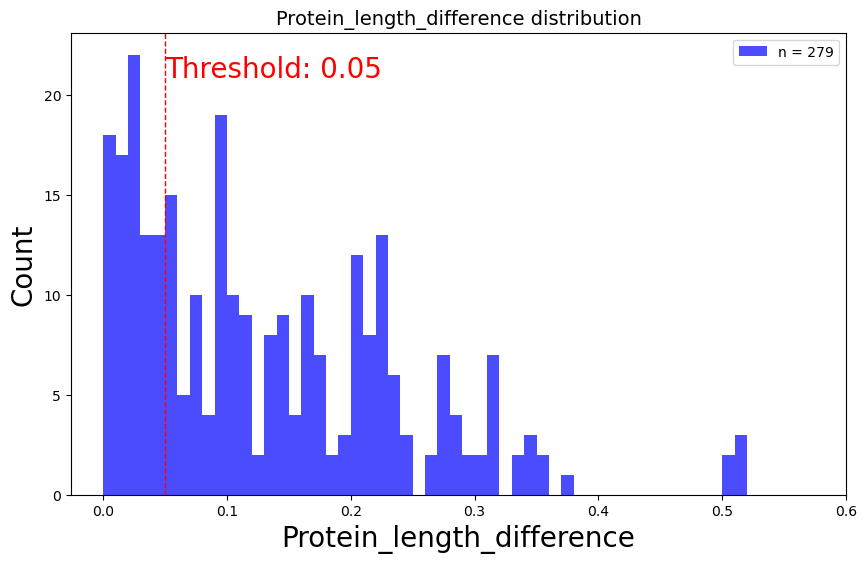

In [42]:
# ============================================================
#               Plot: Protein length difference
# ============================================================

# PLot histogram of `Protein_length_error`
def out_plot(
        figure: plt.Figure,
        out_path: str,
        svg: bool = True,
        png_dpi: int = 1080
) -> None:
    out_path = Path(out_path)
    if svg:
        figure.savefig(out_path.with_suffix(".svg"))
    if png_dpi:
        figure.savefig(out_path.with_suffix(".png"), dpi=png_dpi)
    return None

def plot_hist(
        df: pl.DataFrame,
        col_name: str,
        colour: str = "blue",
        alpha: float = 0.7,
        bin_width: float = 10.0,
        tick_interval: float = 0.1,
        exclude_zeros: bool = False,
        last_bin_leftSide: float = None,
        title: str = "Var distribution",
        title_fontSize: int = 14,
        axis_label_fontSize: int = 10,
        xlabel: str = "Var",
        ylabel: str = "Count",
        threshold: float = None,
        threshold_ann: str = None,
        threshold_ann_side: str = "left",
        dims: Tuple[int, int] = (10, 6),
        out_path: str = None
) -> None:
    
    var = df[col_name].to_numpy().astype(float)
    min, max = var.min(), var.max()
    logger.info(f"{col_name} max: {round(max, 4):,}")
    logger.info(f"{col_name} min: {round(min, 4):,}")
    fig, ax = plt.subplots(figsize=dims)

    if exclude_zeros:
        var = var[var != 0]
        min = var.min()
        logger.info(f"Trimmed min {col_name}: {min}")
        
    if last_bin_leftSide is not None:
        var = np.where(
            var > last_bin_leftSide,
            last_bin_leftSide + bin_width,
            var
        )
        max = var.max()
        def _fmt(x, pos):
            if np.isclose(x, max - bin_width):
                return f"{int(last_bin_leftSide):,}+"
            return f"{int(x):,}"
        
        logger.info(f"Trimmed max {col_name}: {max}")
    
    else:
        def _fmt(x, pos):
            return f"{round(x, 2):,}"

    l = np.floor(min / tick_interval) * tick_interval
    u = np.ceil(max / tick_interval) * tick_interval
    xticks = np.arange(l, u, tick_interval)

    l = np.floor(min / bin_width) * bin_width
    u = np.ceil(max / bin_width) * bin_width
    edges = np.arange(l, u + bin_width, bin_width)

    ax.hist(var, bins=edges, color=colour, alpha=alpha, label=f"n = {var.size:,}")
    ax.legend()
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.xaxis.set_major_formatter(FuncFormatter(_fmt))
    ax.set_xticks(xticks)
    ax.set_xlabel(xlabel, fontsize=axis_label_fontSize)
    ax.set_ylabel(ylabel, fontsize=axis_label_fontSize)
    ax.set_title(title, fontsize=title_fontSize)

    if threshold is not None:
        ax.axvline(x=threshold, color="red", linestyle="--", linewidth=1)
        if threshold_ann is None:
            threshold_ann = f"Threshold: {threshold}"
        ax.text(threshold, ax.get_ylim()[1]*0.95, threshold_ann, color="red", ha=threshold_ann_side, va="top", fontsize=axis_label_fontSize)

    if out_path is not None:
        out_plot(figure=fig, out_path=out_path, svg=True, png_dpi=1080)

    plt.show()

plot_hist(
    df=df_def_extra_metrics,
    col_name=args["var_name_lengthError"],
    tick_interval=0.1,
    bin_width=0.01,
    title=f"{args['var_name_lengthError']} distribution",
    xlabel=args["var_name_lengthError"],
    out_path=f"{args['out_path']}/hist_{args['var_name_lengthError']}",
    threshold=args["threshold_lengthError"],
    axis_label_fontSize=20,
)

# Overlap_ratio

From studying pattern in the following dataset:
```
Query_length	Human_prot_total_length	Target_length	Bacterial_prot_total_length	Overlap_ratio
661	1026	696	1010	0.654455446
628	1014	637	1028	0.619329389
663	1014	620	971 0.638516993
546	1026	516	999	0.516516517
365	369	341	355	0.96056338
```

<br>

Formula for `Overlap_ratio`:
```Python
pl.col("Overlap_ratio") = (
    min([pl.col("Query_length"), pl.col("Target_length")]) 
    / min([pl.col("Human_prot_total_length"), pl.col("Bacterial_prot_total_length")])
)
```



INFO:__main__:Overlap_ratio max: 1.0
INFO:__main__:Overlap_ratio min: 0.1678


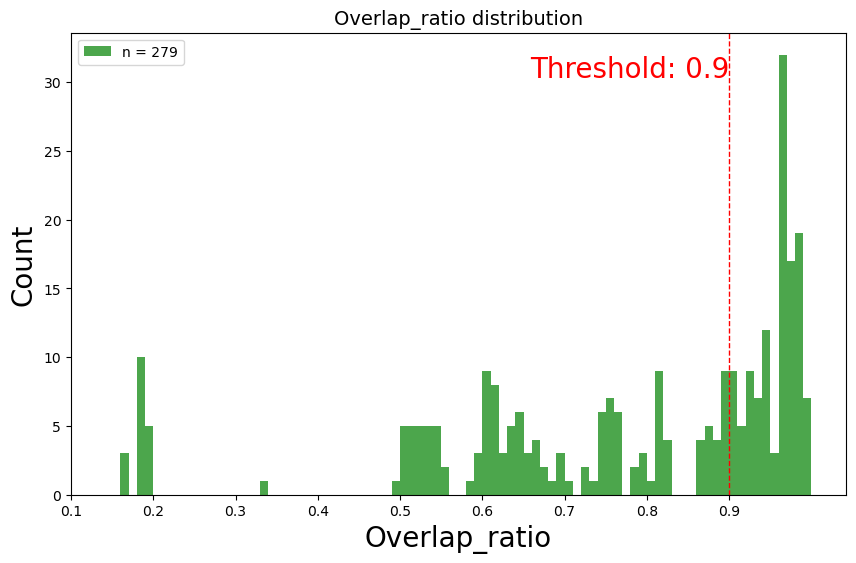

In [43]:
# ============================================================
#                   Plot: Overlap ratio
# ============================================================

plot_hist(
    df=df_def_extra_metrics,
    col_name="Overlap_ratio",
    colour="green",
    tick_interval=0.1,
    bin_width=0.01,
    title=f"Overlap_ratio distribution",
    xlabel="Overlap_ratio",
    axis_label_fontSize=20,
    out_path=f"{args['out_path']}/hist_Overlap_ratio",
    threshold=args["threshold_overlapRatio"],
    threshold_ann_side="right"
)

In [45]:
# ============================================================
#                   Filter by extra metrics
# ============================================================

def filter_extra_metrics(
        df: pl.DataFrame,
        var_length_error: str,
        threshold_length_error: float,
        threshold_overlap_ratio: float
) -> pl.DataFrame:
    
    df = df.filter(
        (pl.col(var_length_error) <= threshold_length_error) &
        (pl.col("Overlap_ratio") >= threshold_overlap_ratio)
    )

    logger.info(f"N rows after filtering by extra metrics: {len(df)}")
    return df

df_def_filtered_extra = filter_extra_metrics(
    df=df_def_extra_metrics,
    var_length_error=args["var_name_lengthError"],
    threshold_length_error=args["threshold_lengthError"],
    threshold_overlap_ratio=args["threshold_overlapRatio"]
)

df_def_filtered_extra.write_csv(
    f"{args['out_path']}/defense_proteins_filtExtra_n={len(df_def_filtered_extra)}.tsv",
    separator="\t",
    include_header=True
)

summarise_protein_matches(df_def_filtered_extra)

df_def_filtered_extra

INFO:__main__:N rows after filtering by extra metrics: 34
INFO:__main__:N protein matches: 34
INFO:__main__:N unique clusters: 3
INFO:__main__:N unique protein pairs: 34
INFO:__main__:shape: (3,)
Series: 'cluster_id' [str]
[
	"A0A1W9R9X2"
	"A0A6I4ZMH2"
	"A0A4P9X374"
]


accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio,GRIID_gene,Protein_length_difference
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64,str,f64
"""WP_017417305.1""","""Wadjet""","""Wadjet_III""","""Bacillus amyloliquefaciens,Bac…","""GCF_013875015_NZ_CP059405_Wadj…","""GCF_003432425.1_NZ_CP023075_00…","""GCF_003432425.1_NZ_CP023075_00…",13,190,"""A0A411A3U6""","""A0A1W9R9X2""","""A0A1W9R9X2""","""A0A2S1ZR87""",0.0,1,0.147,1035,859,0.0,48,1055,3,1037,1.0510e-32,586,"""unreviewed""","""A0A2S1ZR87_HUMAN""","""Structural maintenance of chro…","""SMC6""","""Homo sapiens (Human)""",null,null,"""SMC6""",null,null,"""DNA recombination [GO:0006310]…","""chromosome, centromeric region…","""chromosome, centromeric region…","""ATP binding [GO:0005524]; ATP …","""GO:0000775; GO:0000781; GO:000…",null,"""3.40.50.300:FF:000959; structu…","""3.40.50.300; P-loop containing…","""IPR027417; P-loop_NTPase.;""IPR…","""PTHR19306; STRUCTURAL MAINTENA…","""PF13476; AAA_23; 1.;""",null,null,"""NP_001135758.1; NM_001142286.2…","""48.0..1055.0""",1008,1091,"""50..257""",100.0,20.63,92.39,"""['Rad50/SbcC-type AAA']""","""['ECO:0000259|Pfam:PF13476']""","""3.0..1037.0""",1035,1071,"""5..225""",100.0,21.35,96.64,"""['Rad50/SbcC-type AAA']""","""['ECO:0000259|Pfam:PF13476']""",0.981668,1008.0,0.941176,"""No""",0.018332
"""WP_017417305.1""","""Wadjet""","""Wadjet_III""","""Bacillus amyloliquefaciens,Bac…","""GCF_013875015_NZ_CP059405_Wadj…","""GCF_003432425.1_NZ_CP023075_00…","""GCF_003432425.1_NZ_CP023075_00…",13,190,"""A0A411A3U6""","""A0A1W9R9X2""","""A0A1W9R9X2""","""Q8IY18""",0.0,1,0.136,1032,867,0.0,53,1056,3,1034,8.2640e-31,530,"""reviewed""","""SMC5_HUMAN""","""Structural maintenance of chro…","""SMC5 KIAA0594 SMC5L1""","""Homo sapiens (Human)""",null,null,"""SMC5""","""KIAA0594 SMC5L1""","""UP000005640: Chromosome 9""","""cell division [GO:0051301]; ce…","""cell junction [GO:0030054]; ch…","""cell junction [GO:0030054]; ch…","""ATP binding [GO:0005524]; ATP …","""GO:0000217; GO:0000722; GO:000…",null,"""3.40.50.300:FF:000793; Structu…","""3.40.50.300; P-loop containing…","""IPR027417; P-loop_NTPase.;""IPR…","""PTHR45916; STRUCTURAL MAINTENA…","""PF13476; AAA_23; 1.;""",null,null,"""NP_055925.2; NM_015110.4.;""","""53.0..1056.0""",1004,1101,null,null,null,null,null,null,"""3.0..1034.0""",1032,1071,"""5..225""",100.0,21.41,96.36,"""['Rad50/SbcC-type AAA']""","""['ECO:0000259|Pfam:PF13476']""",0.972752,1004.0,0.937442,"""No""",0.027248
"""WP_017417305.1""","""Wadjet""","""Wadjet_III""","""Bacillus amyloliquefaciens,Bac…","""GCF_013875015_NZ_CP059405_Wadj…","""GCF_003432425.1_NZ_CP023075_00…","""GCF_003432425.1_NZ_CP023075_00…",13,190,"""A0A411A3U6""","""A0A1W9R9X2""","""A0A1W9R9X2""","""Q96SB8""",0.0,1,0.141,1035,865,0.0,48,1055,3,

# To do


1. Try to align randomly selected structures

<br>

2. Filter by e-value
- understand e-values